that will be me following the instructions in the read me file  

In [14]:
import pandas as pd 

pumpkin_frame = pd.read_csv("../data/US-pumpkins.csv")

In [17]:
pumpkin_frame.isnull().sum()

City Name             0
Type               1712
Package               0
Variety               5
Sub Variety        1461
Grade              1757
Date                  0
Low Price             0
High Price            0
Mostly Low          103
Mostly High         103
Origin                3
Origin District    1626
Item Size           279
Color               616
Environment        1757
Unit of Sale       1595
Quality            1757
Condition          1757
Appearance         1757
Storage            1757
Crop               1757
Repack                0
Trans Mode         1757
Unnamed: 24        1757
Unnamed: 25        1654
dtype: int64

looking the empty data the columns that we can use city name package variety date low price high price origin other than these columns we should replace too many empty rows and that will probably lead to uncostistent model

we will use price per bushel so lets filter others 
case works for case unsensitive and na works if its null make it false 

In [18]:
pumpkin_frame = pumpkin_frame[pumpkin_frame['Package'].str.contains('bushel', case=False, na=False)]

In [20]:
pumpkin_frame.describe()

,Grade,Low Price,High Price,Mostly Low,Mostly High,Environment,Quality,Condition,Appearance,Storage,Crop,Trans Mode,Unnamed: 24
count,0.0,415.000000,415.000000,391.000000,391.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
mean,NaN,18.007831,18.989759,18.304348,18.950767,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,5.273335,5.694920,5.320325,5.890913,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,10.750000,12.000000,12.000000,12.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,15.000000,17.000000,15.000000,16.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,17.000000,18.000000,17.000000,18.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,18.000000,19.000000,18.000000,19.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
max,NaN,48.000000,55.000000,48.000000,55.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [21]:
pumpkin_frame.head()

,City Name,Type,Package,Variety,Sub Variety,Grade,Date,Low Price,High Price,Mostly Low,...,Unit of Sale,Quality,Condition,Appearance,Storage,Crop,Repack,Trans Mode,Unnamed: 24,Unnamed: 25
70,BALTIMORE,NaN,1 1/9 bushel cartons,PIE TYPE,NaN,NaN,9/24/16,15.0,15.0,15.0,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN
71,BALTIMORE,NaN,1 1/9 bushel cartons,PIE TYPE,NaN,NaN,9/24/16,18.0,18.0,18.0,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN
72,BALTIMORE,NaN,1 1/9 bushel cartons,PIE TYPE,NaN,NaN,10/1/16,18.0,18.0,18.0,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN
73,BALTIMORE,NaN,1 1/9 bushel cartons,PIE TYPE,NaN,NaN,10/1/16,17.0,17.0,17.0,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN
74,BALTIMORE,NaN,1 1/9 bushel cartons,PIE TYPE,NaN,NaN,10/8/16,15.0,15.0,15.0,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN


In [22]:
pumpkin_frame.isnull().sum()

City Name            0
Type               406
Package              0
Variety              0
Sub Variety        167
Grade              415
Date                 0
Low Price            0
High Price           0
Mostly Low          24
Mostly High         24
Origin               0
Origin District    396
Item Size          114
Color              145
Environment        415
Unit of Sale       404
Quality            415
Condition          415
Appearance         415
Storage            415
Crop               415
Repack               0
Trans Mode         415
Unnamed: 24        415
Unnamed: 25        391
dtype: int64

for this particular example we will use 
package 
date 
low price 
high price 

In [25]:
necessary_columns = ['Package','Low Price','High Price','Date']
pumpkin_data = pumpkin_frame[necessary_columns]

In [27]:
pumpkin_data['Package'].value_counts()

Package
1/2 bushel cartons      234
1 1/9 bushel cartons    117
bushel cartons           37
1 1/9 bushel crates      17
bushel baskets           10
Name: count, dtype: int64

In [35]:
from numpy import mean

def turn_price_per_bushel(row):
    if row['Package'] == 'bushel cartons' or row['Package'] == 'bushel baskets':
        return mean([row['Low Price'], row['High Price']])
    elif row['Package'] == '1/2 bushel cartons':
        return mean([row['Low Price'], row['High Price']]) * 2
    elif row['Package'] == '1 1/9 bushel cartons' or row['Package'] == '1 1/9 bushel crates':
        return mean([row['Low Price'], row['High Price']]) / (10/9)
    else :
        return 1

In [33]:
pumpkin_data['Month'] = pumpkin_data['Date'].str.split('/').str[0]

In [37]:
pumpkin_data['Average Price'] = pumpkin_data.apply(turn_price_per_bushel, axis=1)

In [38]:
pumpkin_data['Average Price'].describe()

count    415.000000
mean      27.656506
std        9.876318
min       10.800000
25%       16.200000
50%       30.000000
75%       35.000000
max       51.500000
Name: Average Price, dtype: float64

In [46]:
monthy_prices = pumpkin_data.groupby('Month')['Average Price'].mean()
type(monthy_prices)

pandas.Series

as u can see even without creating a model we can understand that cheapest price is october and most expensive one is September

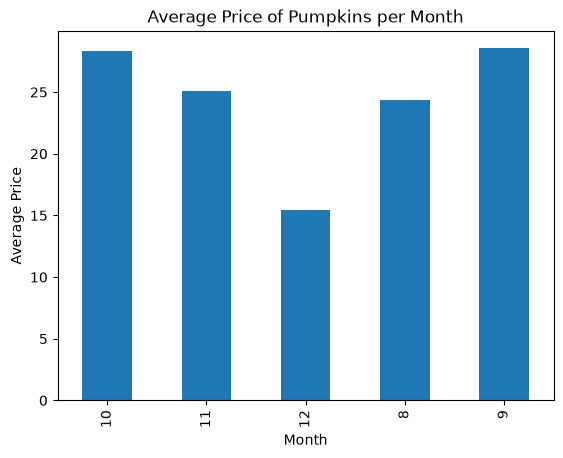

In [44]:
import matplotlib.pyplot as plt

monthy_prices.plot(kind='bar', title='Average Price of Pumpkins per Month', xlabel='Month', ylabel='Average Price')
plt.title('Average Price of Pumpkins per Month')
plt.xlabel('Month')
plt.ylabel('Average Price')
plt.show()

in the lesson they created a scattter plot without making changes as below

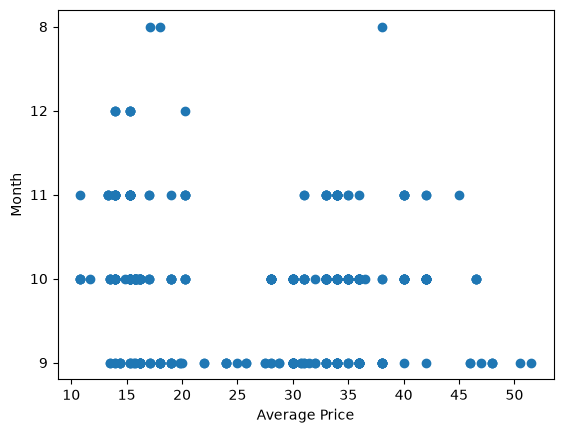

In [48]:
months = pumpkin_data['Month']
prices = pumpkin_data['Average Price']
plt.scatter(prices, months)
plt.xlabel('Average Price')
plt.ylabel('Month')
plt.show()

as I understand we can give a tuple like frame such as variable value type data to plt to turn into any kind of chart that I want 
by the way most used graphic types are bar and scatter they make the first one after this  

assignment is creating data visualizations so I actualy already make the one they want I will skip it 